# Lab 2.2 — Statistical foundations for pricing

*Prerequisite: labs 2.1, 1.1 and 1.2.*

[Lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) produced numbers. This notebook asks the two questions that must
follow any number in a commercial meeting:

1. **Is it real, or is it noise?**
2. **How wrong could it be?**

Pricing is unusually punishing about this. The effects are small (a 20bp
move), the data is noisy (one order in a hundred is ten times the size of
the rest), and the decisions are hard to reverse (put a rate up, and the
customers who left do not tell you they left). Every one of those makes
honest uncertainty more valuable than another decimal place.

We will build the toolkit from scratch: distributions, the average and its
lies, sampling error, confidence intervals, the bootstrap, how much data you
need, and the two traps — correlation and regression to the mean — that
generate more false pricing "insights" than everything else combined.

---

## Randomness has shapes, and the shape matters

A distribution is a description of how a quantity varies. Pricing lives on
six of them; knowing which is which stops you using tools built for one on
data of another.

| Distribution | What it describes | In our business | The thing to remember |
|---|---|---|---|
| **Bernoulli** | A single yes/no | Did this quote convert? | Variance is p(1−p) — biggest at p = 0.5 |
| **Binomial** | Number of yeses in n tries | Orders out of today's quotes | Sum of Bernoullis; SE = √(p(1−p)/n) |
| **Poisson** | Count of arrivals in a window | Customers per day | Variance = mean, so busy days are *also* more variable |
| **Log-normal** | A positive amount built by multiplying effects | Order value | Mean ≫ median; the tail is where the money is |
| **Normal** | Averages of many things | Mean conversion, mean revenue | Earned via the CLT, not assumed |
| **Gamma / exponential** | Waiting times, positive skewed costs | Time between orders, claim severity | Insurance pricing lives here |

Let's confirm the two that matter most.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from toolkit import C, INK, MUT, SUB, load, money, pct, style, tidy, truth

style()
rng = np.random.default_rng(7)

quotes = load("fct_quotes")
txn = load("fct_transactions")
daily = load("fct_daily")

value = txn["order_value_gbp"]
print(f"order value:  mean {money(value.mean(), 0)}   median {money(value.median(), 0)}   "
      f"max {money(value.max(), 0)}")
print(f"skew {value.skew():.2f}   the top 1% of orders carry "
      f"{value[value >= value.quantile(0.99)].sum() / value.sum():.1%} of turnover")

order value:  mean £478   median £400   max £5,160
skew 1.94   the top 1% of orders carry 4.1% of turnover


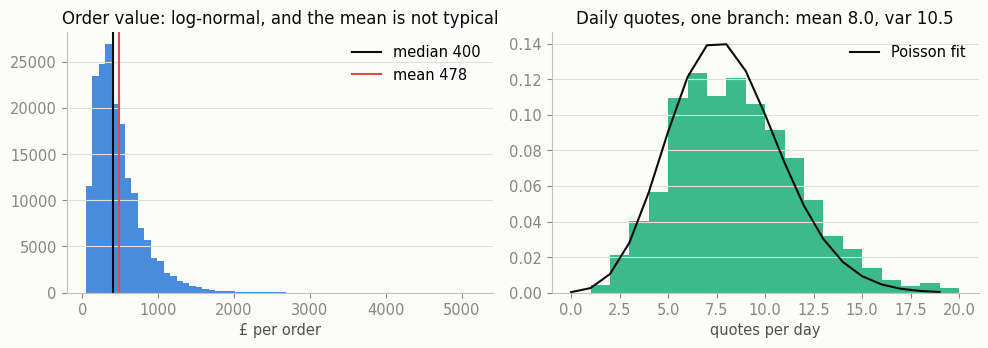

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].hist(value, bins=60, color=C[0], alpha=0.85)
axes[0].axvline(value.median(), color=INK, lw=1.5, label=f"median {value.median():.0f}")
axes[0].axvline(value.mean(), color=C[5], lw=1.5, label=f"mean {value.mean():.0f}")
axes[0].set_title("Order value: log-normal, and the mean is not typical")
axes[0].set_xlabel("£ per order")
axes[0].legend()

footfall = daily.groupby("date")["quotes"].sum()
site_day = daily[daily["site_id"] == "B011"].groupby("date")["quotes"].sum()
axes[1].hist(site_day, bins=range(0, site_day.max() + 2), color=C[1], alpha=0.85, density=True)
x = np.arange(0, site_day.max() + 1)
axes[1].plot(x, stats.poisson.pmf(x, site_day.mean()), color=INK, lw=1.5, label="Poisson fit")
axes[1].set_title(f"Daily quotes, one branch: mean {site_day.mean():.1f}, var {site_day.var():.1f}")
axes[1].set_xlabel("quotes per day")
axes[1].legend()

for ax in axes:
    tidy(ax)
plt.tight_layout()
plt.show()

Two things to take away.

**The order-value histogram has a long right tail.** The mean sits well
above the median because a few enormous orders drag it up. This is
log-normal behaviour and it is the norm for money amounts, because sizes are
built by *multiplying* effects (a bigger trip × a longer stay × a wealthier
household), and multiplying many random factors produces a log-normal, in
the same way that adding many produces a normal.

**Daily counts have variance close to their mean.** That is the Poisson
signature. It has a direct operational consequence: a site averaging 25
quotes a day has a standard deviation of about 5, so days between 15 and 35
are *completely ordinary*. Any dashboard that flags "Tuesday down 20%" as a
finding is generating false alarms about arithmetic that hasn't happened
yet. (Our real variance runs a little above the Poisson line because the
mean itself moves with the season — "over-dispersion", the reason the
negative binomial exists.)

## The average, and four ways it lies

> "The average customer" does not exist, and building a price for them
> serves nobody.

| Trap | What happens | Our example |
|---|---|---|
| **Skew** | The mean describes almost no one | Mean order £486, median £400; most orders are below the mean |
| **Mixtures** | An average across two populations describes neither | The blended conversion of a captive airport and a shopping app |
| **Unweighted means of ratios** | Every row counts equally regardless of size | Averaging daily margin % instead of weighting by turnover |
| **Averaging away the tail** | The rare, huge cases are where the risk is | Top 1% of orders = a meaningful slice of turnover |

The third one is worth doing explicitly, because it is the most common
mistake in commercial reporting and it looks harmless.

In [3]:
naive_avg = daily["avg_quoted_margin_pp"].mean()
weighted_avg = (txn["order_value_gbp"] * txn["margin_pp"]).sum() / txn["order_value_gbp"].sum()

print(f"unweighted mean of daily average margins : {naive_avg:.3f}pp")
print(f"turnover-weighted realised margin        : {weighted_avg:.3f}pp")
print(f"difference                               : {100 * (weighted_avg - naive_avg):+.0f}bp\n")
print(f"On {money(txn['order_value_gbp'].sum() / 1e6, 1)}m of turnover that gap is worth "
      f"{money(abs(weighted_avg - naive_avg) / 100 * txn['order_value_gbp'].sum())} of revenue - "
      "the sort of error that survives three layers of review because both numbers are 'the average margin'.")

unweighted mean of daily average margins : 3.489pp
turnover-weighted realised margin        : 3.471pp
difference                               : -2bp

On £85.0m of turnover that gap is worth £15,525 of revenue - the sort of error that survives three layers of review because both numbers are 'the average margin'.


## Sampling: why your number is not the number

Every figure you compute is from a **sample** — the customers who happened
to walk in — and you want to say something about the **population**: what
customers *would* do. The gap between them is sampling error, and it obeys a
law simple enough to do in your head:

```
standard error  ≈  σ / √n
```

The **√n** is the whole story. To halve your uncertainty you need four times
the data. To get a tenth of the uncertainty you need a hundred times. This
is why "let's run the test another week" is often a bad deal and "let's test
a bigger move" is often a good one.

For a conversion rate the formula specialises to:

```
SE(p) = √( p(1−p) / n )
```

Let's check that the formula matches reality by resampling our own data.

In [4]:
online = quotes[quotes["channel"] == "online"]
p_true_online = online["converted"].mean()

for n in [100, 400, 1600, 6400]:
    draws = np.array([online["converted"].sample(n, replace=True, random_state=i).mean()
                      for i in range(400)])
    formula = np.sqrt(p_true_online * (1 - p_true_online) / n)
    print(f"n = {n:5d}   observed SE {draws.std():.4f}   formula {formula:.4f}   "
          f"typical error ±{1.96 * draws.std() * 100:.1f}pp")

n =   100   observed SE 0.0494   formula 0.0489   typical error ±9.7pp


n =   400   observed SE 0.0249   formula 0.0244   typical error ±4.9pp


n =  1600   observed SE 0.0122   formula 0.0122   typical error ±2.4pp


n =  6400   observed SE 0.0062   formula 0.0061   typical error ±1.2pp


Read the last column as a business constraint. With 400 quotes you cannot
see anything smaller than about ±5pp of conversion. Our A/B test in [lab 2.4](lab_04_experiments_and_ab_testing.ipynb) has around 2,100 quotes per arm, giving roughly ±2pp — which is why it
can detect the true 6.5pp effect comfortably, and could *not* have detected
a 1pp effect.

**Decide what you need to see before you run the test, not after.**

## Confidence intervals — and what they do not mean

A 95% confidence interval is the range of values that would not be
surprising, given the data.

- ✅ "If we repeated this exercise many times, 95% of the intervals we
  construct would contain the true value."
- ❌ "There is a 95% probability the truth is in this interval." (That is a
  Bayesian credible interval; often what people mean, not what a CI is.)
- ❌ "The effect is zero because the interval contains zero." Absence of
  evidence is not evidence of absence — a wide interval containing zero and
  also containing a commercially enormous number is a statement about your
  sample size, not about the world.

The practical translation for a pricing decision:

> An interval of [−1%, +9%] does not mean "no effect". It means **the data
> cannot tell you** whether this was a disaster or a triumph. The correct
> response is to say so, then either get more data or make the decision on
> other grounds — and be explicit about which you did.

In [5]:
def wilson_interval(successes, n, z=1.96):
    """Confidence interval for a proportion. Behaves near 0 and 1, unlike the normal approximation."""
    p = successes / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half


rows = []
for label, grp in list(quotes.groupby("channel")) + list(
        quotes[quotes["channel"] == "branch"].groupby("region_id"))[:4]:
    lo, hi = wilson_interval(grp["converted"].sum(), len(grp))
    rows.append({"group": label, "quotes": len(grp), "conversion": grp["converted"].mean(),
                 "95% CI": f"[{lo:.3f}, {hi:.3f}]", "width_pp": round(100 * (hi - lo), 2)})
print(pd.DataFrame(rows).to_string(index=False))

  group  quotes  conversion         95% CI  width_pp
airport   56603    0.601611 [0.598, 0.606]      0.81
 branch  145549    0.539104 [0.537, 0.542]      0.51
 online  107394    0.606524 [0.604, 0.609]      0.58
    R01   14166    0.551179 [0.543, 0.559]      1.64
    R02   13390    0.557058 [0.549, 0.565]      1.68
    R03   10928    0.515922 [0.507, 0.525]      1.87
    R04   11849    0.546460 [0.537, 0.555]      1.79


Note the widths: with tens of thousands of quotes per channel, conversion is
pinned to within a fraction of a point; drop to one region's branches and
the interval widens by roughly a factor of three. Conversion is a *cheap*
metric — it uses every quote and every quote counts the same — but "cheap"
still obeys the √n law, and a single region is a much smaller n than it
feels like.

Revenue per quote is a different animal, and this is where pricing analytics
gets hard.

In [6]:
quotes["revenue_per_quote"] = np.where(
    quotes["converted"] == 1, quotes["order_value_gbp"] * quotes["quoted_margin_pp"] / 100, 0.0)

r = quotes["revenue_per_quote"]
print(f"revenue per quote: mean £{r.mean():.2f}   sd £{r.std():.2f}   "
      f"coefficient of variation {r.std() / r.mean():.2f}")
print(f"conversion:        mean {quotes['converted'].mean():.3f}   sd {quotes['converted'].std():.3f}   "
      f"coefficient of variation {quotes['converted'].std() / quotes['converted'].mean():.2f}")
print("\nSame number of observations. The money metric is roughly "
      f"{(r.std() / r.mean()) / (quotes['converted'].std() / quotes['converted'].mean()):.1f}x noisier, "
      "because it inherits the log-normal tail of order sizes.")

revenue per quote: mean £9.53   sd £12.50   coefficient of variation 1.31
conversion:        mean 0.574   sd 0.495   coefficient of variation 0.86

Same number of observations. The money metric is roughly 1.5x noisier, because it inherits the log-normal tail of order sizes.


This is the single most important practical fact in pricing experimentation,
and it catches people out constantly:

> **The metric you care about is the noisiest one you have.** Conversion is
> tidy and answers the wrong question. Revenue and contribution answer the
> right question and need far more data — or a variance-reduction trick — to
> answer it precisely.

[Lab 2.4](lab_04_experiments_and_ab_testing.ipynb) shows both the problem and the standard fixes (winsorising,
CUPED-style covariate adjustment, and using the ratio metric properly).

## The bootstrap: uncertainty without formulas

When a metric is not a simple mean — a ratio, a median, a
turnover-weighted margin, the output of an optimisation — the textbook
standard-error formula either doesn't exist or doesn't apply. The
**bootstrap** solves this by brute force:

1. Resample your data *with replacement* to the same size.
2. Recompute the statistic.
3. Repeat a few thousand times.
4. The spread of those values is the sampling distribution.

It works because your sample is the best available stand-in for the
population, so resampling from it mimics drawing fresh samples from the
world. It is one of the few genuinely free lunches in statistics — and it is
particularly valuable in pricing, where the quantities that matter
(realised margin, contribution per quote, an optimal price) are almost never
simple means.

realised margin      3.4674pp
bootstrap 95% CI     [3.4375, 3.4977]  (width 6.0bp)
bootstrap SE         0.0154pp


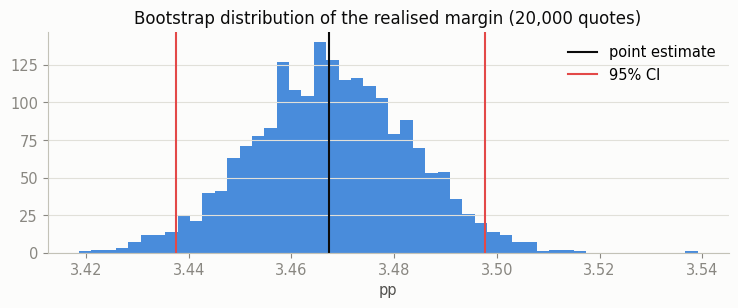

In [7]:
sample = quotes.sample(20000, random_state=1)
vals = sample["order_value_gbp"].to_numpy()
margins = sample["quoted_margin_pp"].to_numpy()
converted = sample["converted"].to_numpy()

def realised_margin(idx):
    """Turnover-weighted realised margin - a ratio of two sums, not a mean."""
    won = converted[idx] == 1
    return (vals[idx][won] * margins[idx][won]).sum() / vals[idx][won].sum()

point = realised_margin(np.arange(len(sample)))
boot = np.array([realised_margin(rng.integers(0, len(sample), len(sample))) for _ in range(2000)])
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"realised margin      {point:.4f}pp")
print(f"bootstrap 95% CI     [{lo:.4f}, {hi:.4f}]  (width {100 * (hi - lo):.1f}bp)")
print(f"bootstrap SE         {boot.std():.4f}pp")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(boot, bins=50, color=C[0], alpha=0.85)
for x, colour, label in [(point, INK, "point estimate"), (lo, C[5], "95% CI"), (hi, C[5], None)]:
    ax.axvline(x, color=colour, lw=1.5, label=label)
ax.set_title("Bootstrap distribution of the realised margin (20,000 quotes)")
ax.set_xlabel("pp")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

## How much data do you need? (Power, in advance)

Before running any test, answer: *what is the smallest effect I would act
on, and can this test see it?* That threshold is the **minimum detectable
effect (MDE)**.

For a two-arm test with equal splits, 95% confidence and 80% power, the
rule of thumb is:

```
n per arm  ≈  16 × σ² / Δ²        (Δ = effect you want to detect)
```

The 16 is (1.96 + 0.84)² ≈ 7.85, doubled for two arms. Two things fall out
of the Δ² immediately: **halving the effect you want to detect quadruples
the sample**, and **the noisier the metric, the more you need**. Let's price
that out for our online channel.

In [8]:
def sample_size(sd, effect, alpha_z=1.96, power_z=0.84):
    return int(np.ceil(2 * (alpha_z + power_z) ** 2 * sd ** 2 / effect ** 2))


p0 = online["converted"].mean()
sd_conv = np.sqrt(p0 * (1 - p0))
sd_rev = quotes.loc[quotes["channel"] == "online", "revenue_per_quote"].std()
mean_rev = quotes.loc[quotes["channel"] == "online", "revenue_per_quote"].mean()
online_quotes_per_day = quotes[quotes["channel"] == "online"].groupby("date").size().mean()

rows = []
for label, sd, effect in [("conversion, detect 1pp", sd_conv, 0.01),
                          ("conversion, detect 3pp", sd_conv, 0.03),
                          ("conversion, detect 7pp (our true effect)", sd_conv, 0.069),
                          ("revenue/quote, detect 2%", sd_rev, 0.02 * mean_rev),
                          ("revenue/quote, detect 5%", sd_rev, 0.05 * mean_rev),
                          ("revenue/quote, detect 10%", sd_rev, 0.10 * mean_rev)]:
    n = sample_size(sd, effect)
    rows.append({"target": label, "n per arm": f"{n:,}",
                 "days of online traffic": f"{2 * n / online_quotes_per_day:.0f}"})
print(f"online traffic: {online_quotes_per_day:.0f} quotes/day\n")
print(pd.DataFrame(rows).to_string(index=False))

online traffic: 98 quotes/day

                                  target n per arm days of online traffic
                  conversion, detect 1pp    37,421                    764
                  conversion, detect 3pp     4,158                     85
conversion, detect 7pp (our true effect)       786                     16
                revenue/quote, detect 2%    61,009                   1245
                revenue/quote, detect 5%     9,762                    199
               revenue/quote, detect 10%     2,441                     50


Read that table as a *design* document, not a statistics exercise.

- Detecting a 1pp conversion change needs months of traffic. If your
  proposed test is worth running only if it moves conversion by 1pp, you do
  not have a test — you have a wish.
- Detecting a 2% revenue-per-quote change needs even more, because of the
  tail.
- Our actual experiment ran eight weeks and had ample power for the effect
  that was really there. That was luck as much as design; it is cheap to
  check in advance and expensive to discover afterwards.

> **The most valuable sentence in experiment design:** "With the traffic we
> have, in the time we have, the smallest effect we could reliably detect is
> X. Is X small enough to be worth knowing?" Ask it before the test, and
> half of all bad tests never get run.

## Two traps that manufacture false insight

### Correlation is not causation — and in pricing it is usually *reversed*

The generic warning is well known and slightly useless, because it doesn't
say what to look for. In pricing the specific pattern is:

> **Prices are set by people who know things.** Whenever price appears to
> have a weak or wrong-signed effect, suspect that price was *responding* to
> demand rather than driving it.

That is exactly what [lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) found, and [lab 2.3](lab_03_regression_for_pricing.ipynb) and [lab 2.5](lab_05_causal_inference.ipynb) fix. Three
questions defuse most cases:

1. Who set this price, and what were they looking at when they set it?
2. What else changed at the same time?
3. What would this relationship look like if the causality ran the other
   way — and can I tell the two apart with the data I have?

### Regression to the mean

If you pick the extreme cases and look again later, they will be less
extreme — not because anything changed, but because extremes are part luck
and luck doesn't repeat.

This manufactures fake results daily: the "best branch" wins an award and
declines; the intervention applied to the worst-performing week "works"; a
new pricing model looks brilliant on the outliers it was tuned to. Let's
watch it happen in our own data, where we know for a fact that nothing
happened.

In [9]:
weekly = (quotes.assign(week=quotes["date"].dt.to_period("W"))
          .groupby(["region_id", "week"])
          .agg(quotes=("quote_id", "count"), conv=("converted", "mean"))
          .reset_index())
weekly = weekly[weekly["quotes"] >= 50].sort_values(["region_id", "week"])
weekly["next_conv"] = weekly.groupby("region_id")["conv"].shift(-1)
weekly = weekly.dropna()

top = weekly[weekly["conv"] >= weekly["conv"].quantile(0.90)]
bottom = weekly[weekly["conv"] <= weekly["conv"].quantile(0.10)]
overall = weekly["conv"].mean()

print(f"overall weekly conversion            {overall:.3f}")
print(f"best 10% of weeks                    {top['conv'].mean():.3f}   "
      f"-> next week {top['next_conv'].mean():.3f}   ({100 * (top['next_conv'].mean() - top['conv'].mean()):+.1f}pp)")
print(f"worst 10% of weeks                   {bottom['conv'].mean():.3f}   "
      f"-> next week {bottom['next_conv'].mean():.3f}   ({100 * (bottom['next_conv'].mean() - bottom['conv'].mean()):+.1f}pp)")
print("\nNobody did anything. Both groups moved towards the middle, and if you had")
print("'intervened' on the worst weeks you would now be presenting a success story.")

overall weekly conversion            0.572
best 10% of weeks                    0.656   -> next week 0.585   (-7.0pp)
worst 10% of weeks                   0.485   -> next week 0.552   (+6.7pp)

Nobody did anything. Both groups moved towards the middle, and if you had
'intervened' on the worst weeks you would now be presenting a success story.


The defence is structural, not statistical: **a control group**. If the best
weeks fall back and a comparable untouched group also falls back, you have
learned that nothing happened. That is the entire logic of [lab 2.4](lab_04_experiments_and_ab_testing.ipynb).

## Practice

1. A branch converts 60% of 50 quotes on Monday and 48% of 50 on Tuesday.
   The manager asks what went wrong. What do you say?
2. You are asked to prove a 0.5% improvement in revenue per quote from a
   rate change on the online channel. Roughly how much traffic do you need,
   and what would you propose instead?
3. Your realised margin is 3.556pp with a bootstrap 95% CI of about ±3bp,
   and your true elasticity estimate is −18.5%/pp with a standard error of
   0.7. Which of those two numbers is trustworthy, and why is the answer not
   "both, look at the intervals"?

<details>
<summary>Answers</summary>

1. Nothing detectable. SE of a 50-quote conversion rate is
   √(0.5×0.5/50) ≈ 7pp, so the SE of the *difference* is about 10pp. A 12pp
   swing is well inside ordinary noise. The honest answer is "that is the
   size of gap we would see most weeks by chance; to see a real 12pp change
   we would need about 250 quotes per day." Then ask what would have to be
   true for it to matter.

2. 0.5% of about £10 is £0.05, against a standard deviation near £14:
   n ≈ 16 × 14² / 0.05² — over a million quotes per arm, or decades of
   online traffic.
   The proposal is not testable as stated. Alternatives: test a **larger**
   price move (effects scale with the move, sample requirements don't);
   switch to a less noisy outcome (conversion, plus a modelled revenue
   translation); reduce variance (cap extreme order values, adjust for
   pre-period covariates); or accept a modelled rather than experimental
   answer and say so out loud.

3. The margin. Not because its interval is narrower — narrowness is not
   trustworthiness — but because it is a **descriptive** quantity computed
   from the very data it describes, so sampling error is the only error it
   has. The elasticity is a **causal** claim, and its standard error
   measures only noise around a possibly-biased centre. [Lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb) showed
   that same estimator being off by a factor of ten with a t-statistic of
   −12. Precision and correctness are different things, and confidence
   intervals only ever speak to the first.

</details>

---

**Next:** `05_regression_for_pricing.ipynb` — the workhorse model, what its
coefficients really mean, and the exact formula for how badly a missing
variable will mislead you.